# 📊 Exploratory Data Analysis — Cold Chain Supply Chain

> **Dataset:** Feature-engineered output from `FeatureEngineering.ipynb`  
> **Rows:** 180,519 &nbsp;|&nbsp; **Columns:** 21  
> **Purpose:** Understand distributions, relationships, and patterns in the engineered features to guide predictive modelling for cold chain simulation, logistics risk, and quality degradation.

---

| # | Section | Focus |
|---|---------|-------|
| 1 | Dataset Overview | Shape, dtypes, nulls, descriptive statistics |
| 2 | Univariate Analysis | Distributions of numeric & categorical variables |
| 3 | Bivariate Analysis | Feature vs. target / feature-feature relationships |
| 4 | Correlation Analysis | Heatmap + top correlations |
| 5 | Cold Chain Deep Dive | RouteRisk, TempDev, QualityDegradation patterns |
| 6 | Key Findings & Takeaways | Summary of actionable insights |


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Aesthetic configuration ──
sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('coolwarm', 8)
CAT_PALETTE = sns.color_palette('Set2', 8)

print("✅ Libraries loaded and styling configured.")


✅ Libraries loaded and styling configured.


## 2. Load Data

In [2]:
path = "./data/cold_chain_supply_chain.csv"
df = pd.read_csv(path)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 180,519 rows × 21 columns


,order date (DateOrders),Order Item Quantity,Sales,Shipping Mode,Market,Category Name,Order Region,Product Price,Latitude,Longitude,...,Days for shipment (scheduled),Late_delivery_risk,Delay,Distance,Delay_norm,Distance_norm,RouteRisk,TempDev,QualityDegradation,RefrigerationCost
0,1/31/2018 22:56,1,327.75,Standard Class,Pacific Asia,Sporting Goods,Southeast Asia,327.75,18.251453,-66.037056,...,4,0,-1,3933.139271,0.00,0.268650,0.080595,0.024716,99.876497,3933.139271
1,1/13/2018 12:27,1,327.75,Standard Class,Pacific Asia,Sporting Goods,South Asia,327.75,18.279451,-66.037064,...,4,1,1,3930.958376,0.25,0.268499,0.480550,0.269702,97.434961,3930.958376
2,1/13/2018 12:06,1,327.75,Standard Class,Pacific Asia,Sporting Goods,South Asia,327.75,37.292233,-121.881279,...,4,0,0,2039.700242,0.00,0.137621,0.041286,0.012661,99.936714,2039.700242
3,1/13/2018 11:45,1,327.75,Standard Class,Pacific Asia,Sporting Goods,Oceania,327.75,34.125946,-118.291016,...,4,0,-1,1857.463232,0.00,0.125010,0.037503,0.011501,99.942512,1857.463232
4,1/13/2018 11:24,1,327.75,Standard Class,Pacific Asia,Sporting Goods,Oceania,327.75,18.253769,-66.037048,...,4,0,-2,3932.959485,0.00,0.268637,0.080591,0.024715,99.876503,3932.959485


## 3. Dataset Overview

### 3.1 Column Types & Missing Values

In [3]:
overview = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.notnull().sum(),
    'Nulls': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique(),
    'Sample': df.iloc[0]
})
overview


,Type,Non-Null,Nulls,Null %,Unique,Sample
order date (DateOrders),object,180519,0,0.0,65752,1/31/2018 22:56
Order Item Quantity,int64,180519,0,0.0,5,1
Sales,float64,180519,0,0.0,193,327.75
Shipping Mode,object,180519,0,0.0,4,Standard Class
Market,object,180519,0,0.0,5,Pacific Asia
Category Name,object,180519,0,0.0,50,Sporting Goods
Order Region,object,180519,0,0.0,23,Southeast Asia
Product Price,float64,180519,0,0.0,75,327.75
Latitude,float64,180519,0,0.0,11250,18.251453
Longitude,float64,180519,0,0.0,4487,-66.037056


### 3.2 Descriptive Statistics — Numeric Features

In [4]:
df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.2f}')


,count,mean,std,min,25%,50%,75%,max
Order Item Quantity,180519.00,2.13,1.45,1.00,1.00,1.00,3.00,5.00
Sales,180519.00,203.77,132.27,9.99,119.98,199.92,299.95,1999.99
Product Price,180519.00,141.23,139.73,9.99,50.00,59.99,199.99,1999.99
Latitude,180519.00,29.72,9.81,-33.94,18.27,33.14,39.28,48.78
Longitude,180519.00,-84.92,21.43,-158.03,-98.45,-76.85,-66.37,115.26
Days for shipping (real),180519.00,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.00,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Late_delivery_risk,180519.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Delay,180519.00,0.57,1.49,-2.00,0.00,1.00,1.00,4.00
Distance,180519.00,2525.20,1234.15,51.00,1662.10,2059.50,3907.53,14501.57


### 3.3 Descriptive Statistics — Categorical Features

In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n{'─'*50}")
    print(f"📌 {col}  ({df[col].nunique()} unique)")
    print(df[col].value_counts().head(10).to_string())



──────────────────────────────────────────────────
📌 order date (DateOrders)  (65752 unique)
order date (DateOrders)
12/14/2016 12:29    5
2/22/2015 14:38     5
2/17/2016 14:08     5
12/31/2016 9:50     5
2/11/2016 16:35     5
12/8/2015 17:54     5
1/31/2016 2:46      5
2/9/2016 14:08      5
11/21/2016 1:29     5
2/12/2016 11:10     5

──────────────────────────────────────────────────
📌 Shipping Mode  (4 unique)
Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737

──────────────────────────────────────────────────
📌 Market  (5 unique)
Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614

──────────────────────────────────────────────────
📌 Category Name  (50 unique)
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Cam

## 4. Univariate Analysis

### 4.1 Distribution of Key Numeric Variables

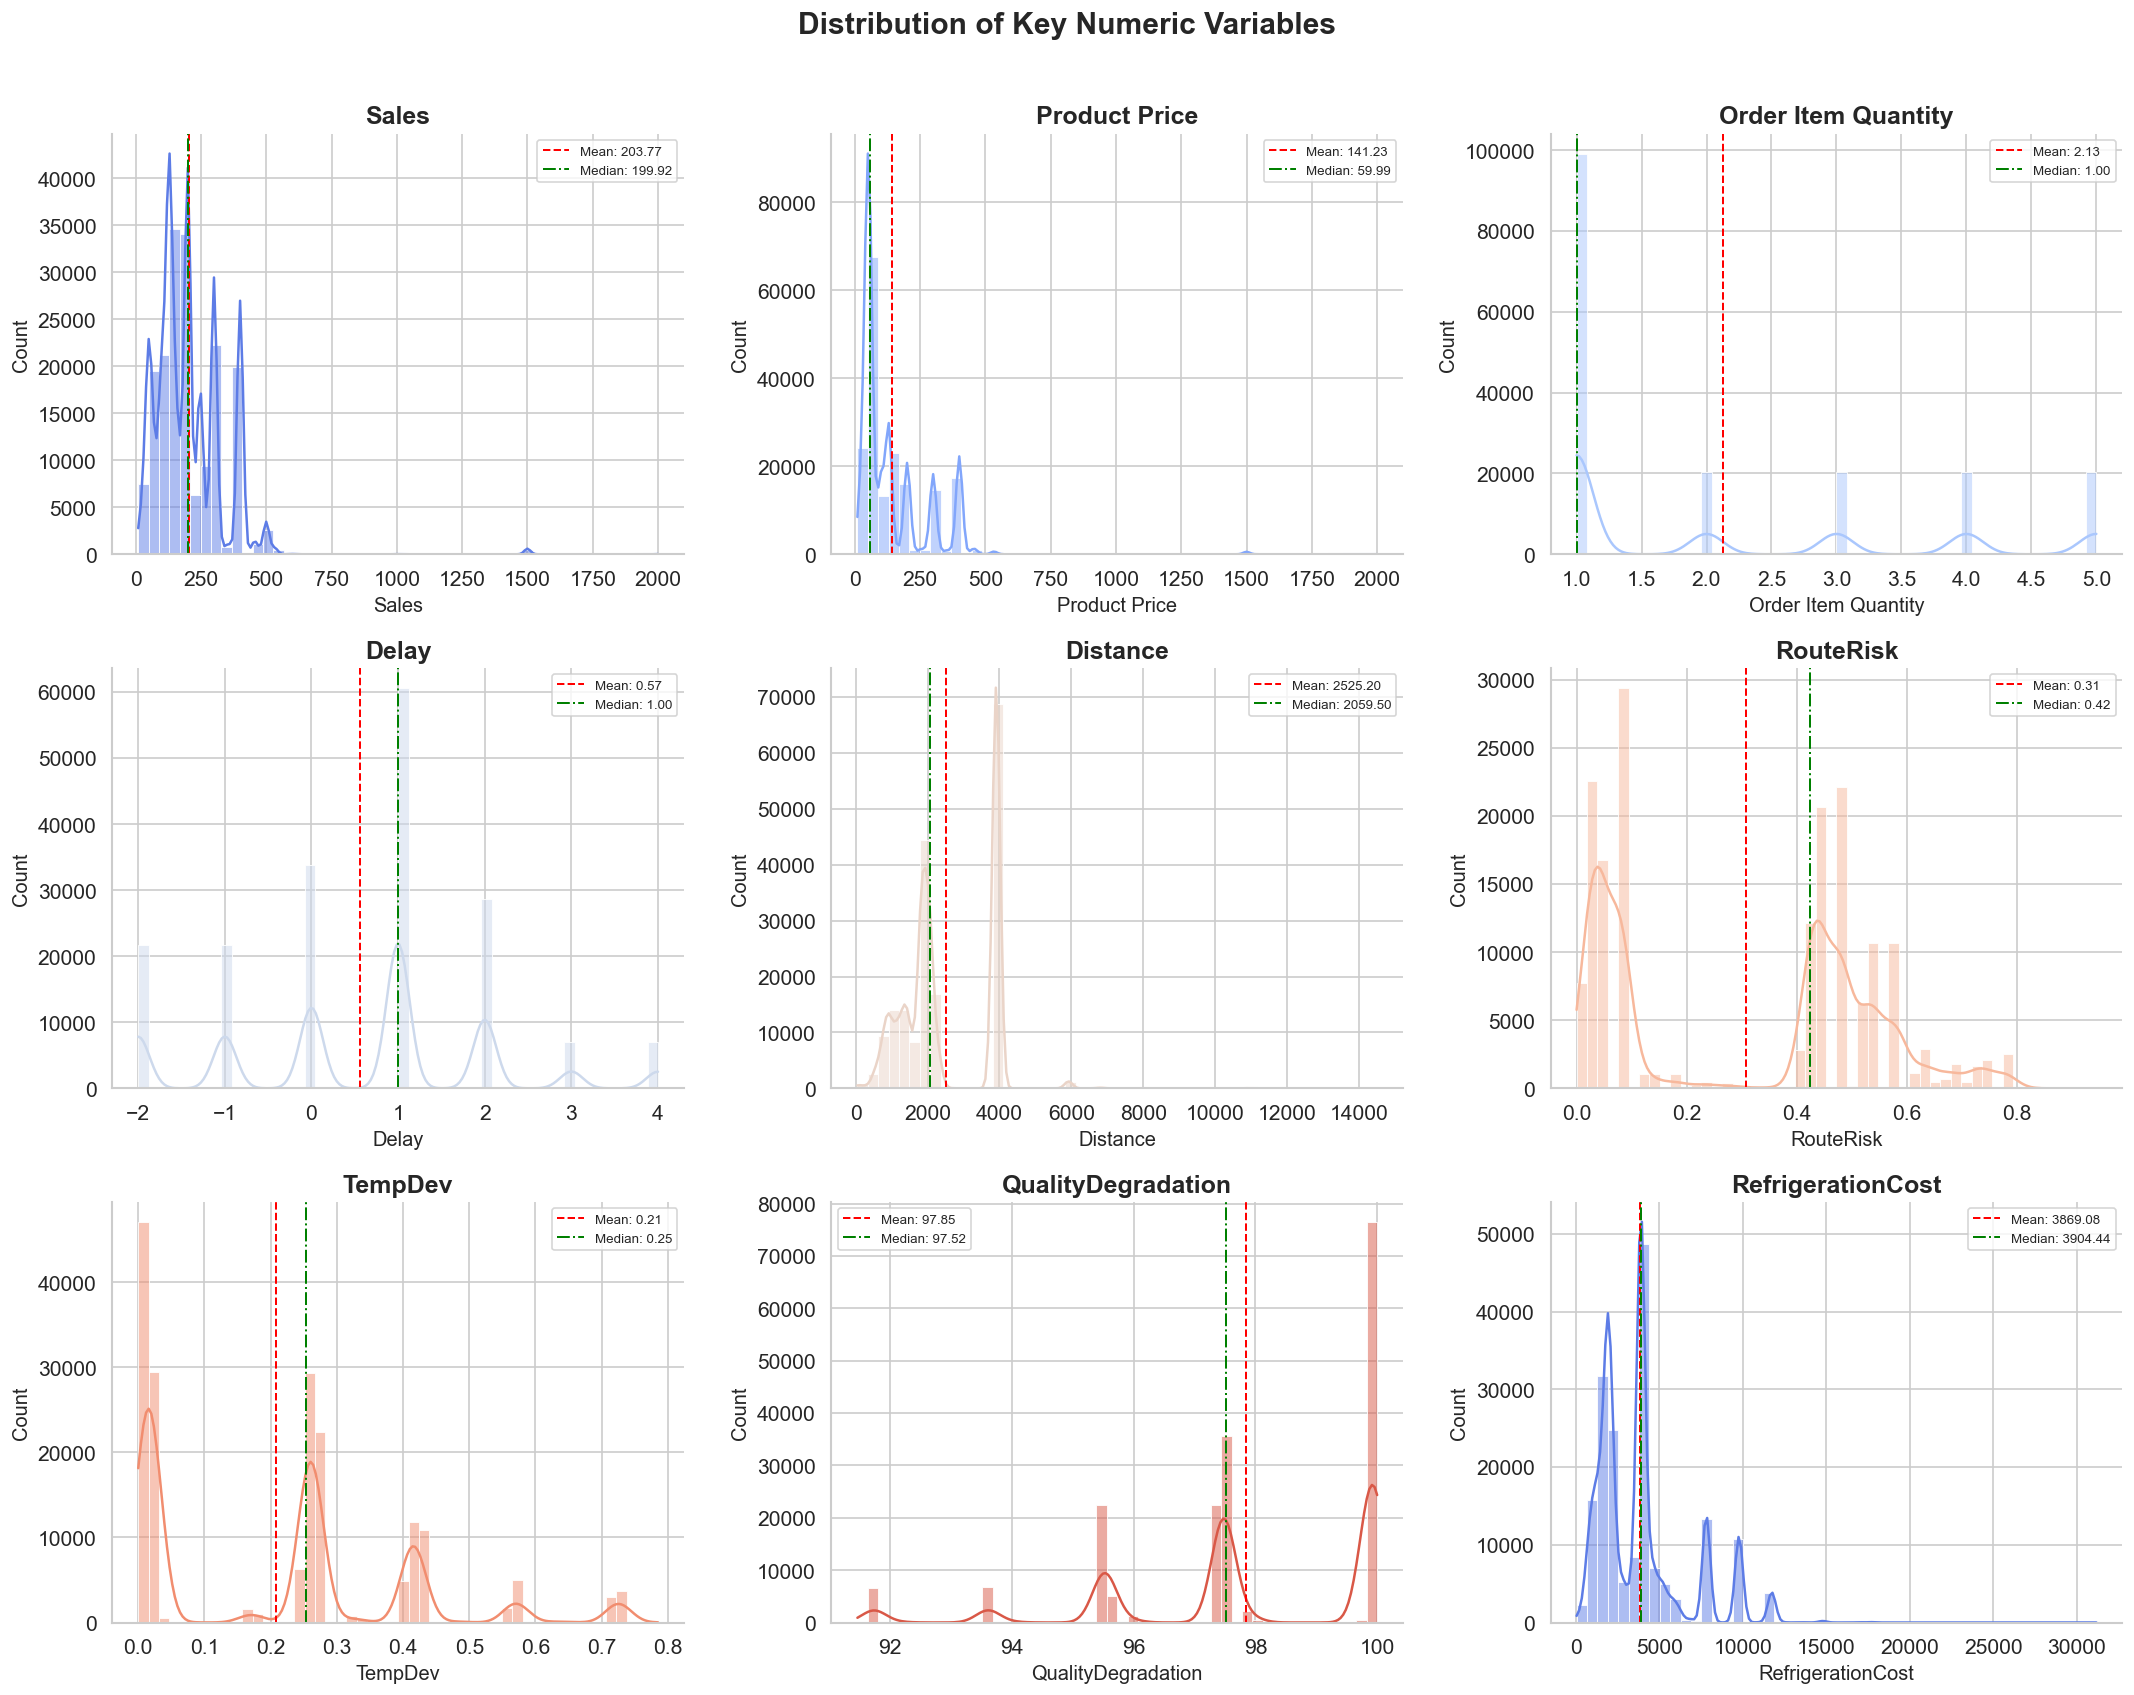

In [6]:
num_features = ['Sales', 'Product Price', 'Order Item Quantity',
                'Delay', 'Distance', 'RouteRisk', 'TempDev',
                'QualityDegradation', 'RefrigerationCost']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color=PALETTE[i % len(PALETTE)],
                 edgecolor='white', linewidth=0.5, bins=50)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-.', linewidth=1.2, label=f'Median: {df[col].median():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Variables', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.2 Box Plots — Outlier Detection

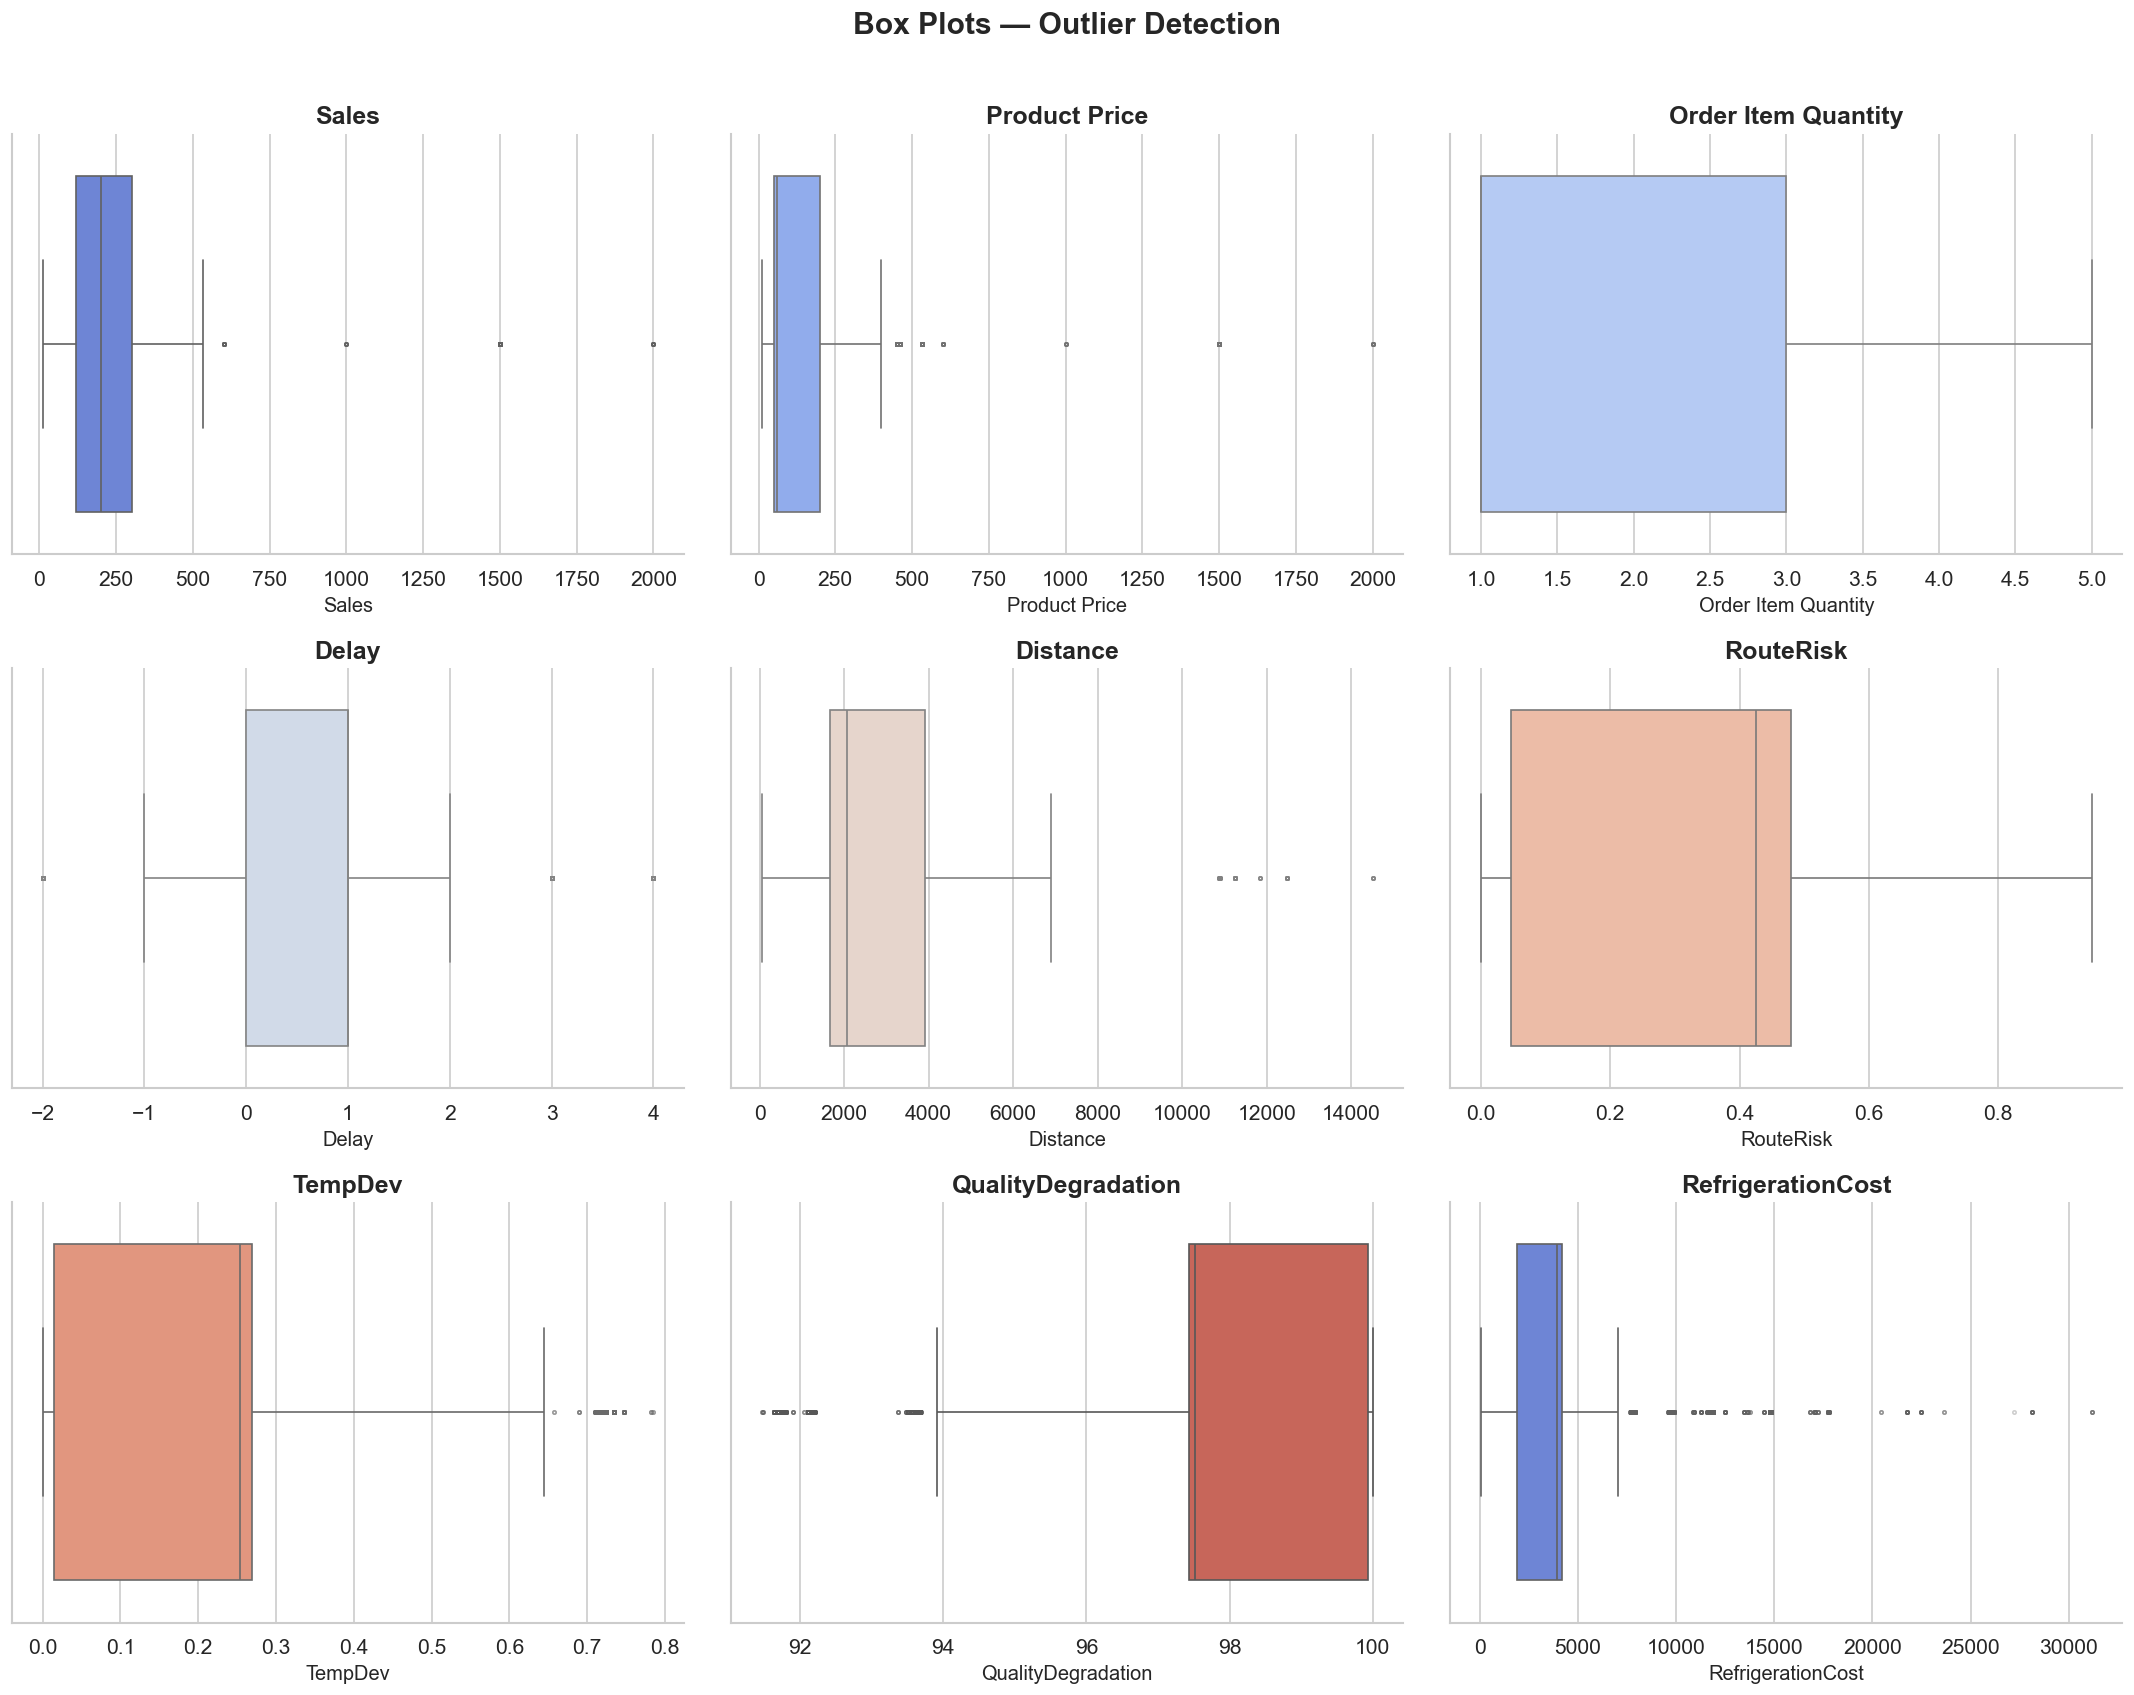

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    sns.boxplot(x=df[col], ax=ax, color=PALETTE[i % len(PALETTE)],
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontweight='bold')

plt.suptitle('Box Plots — Outlier Detection', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Categorical Variable Distributions

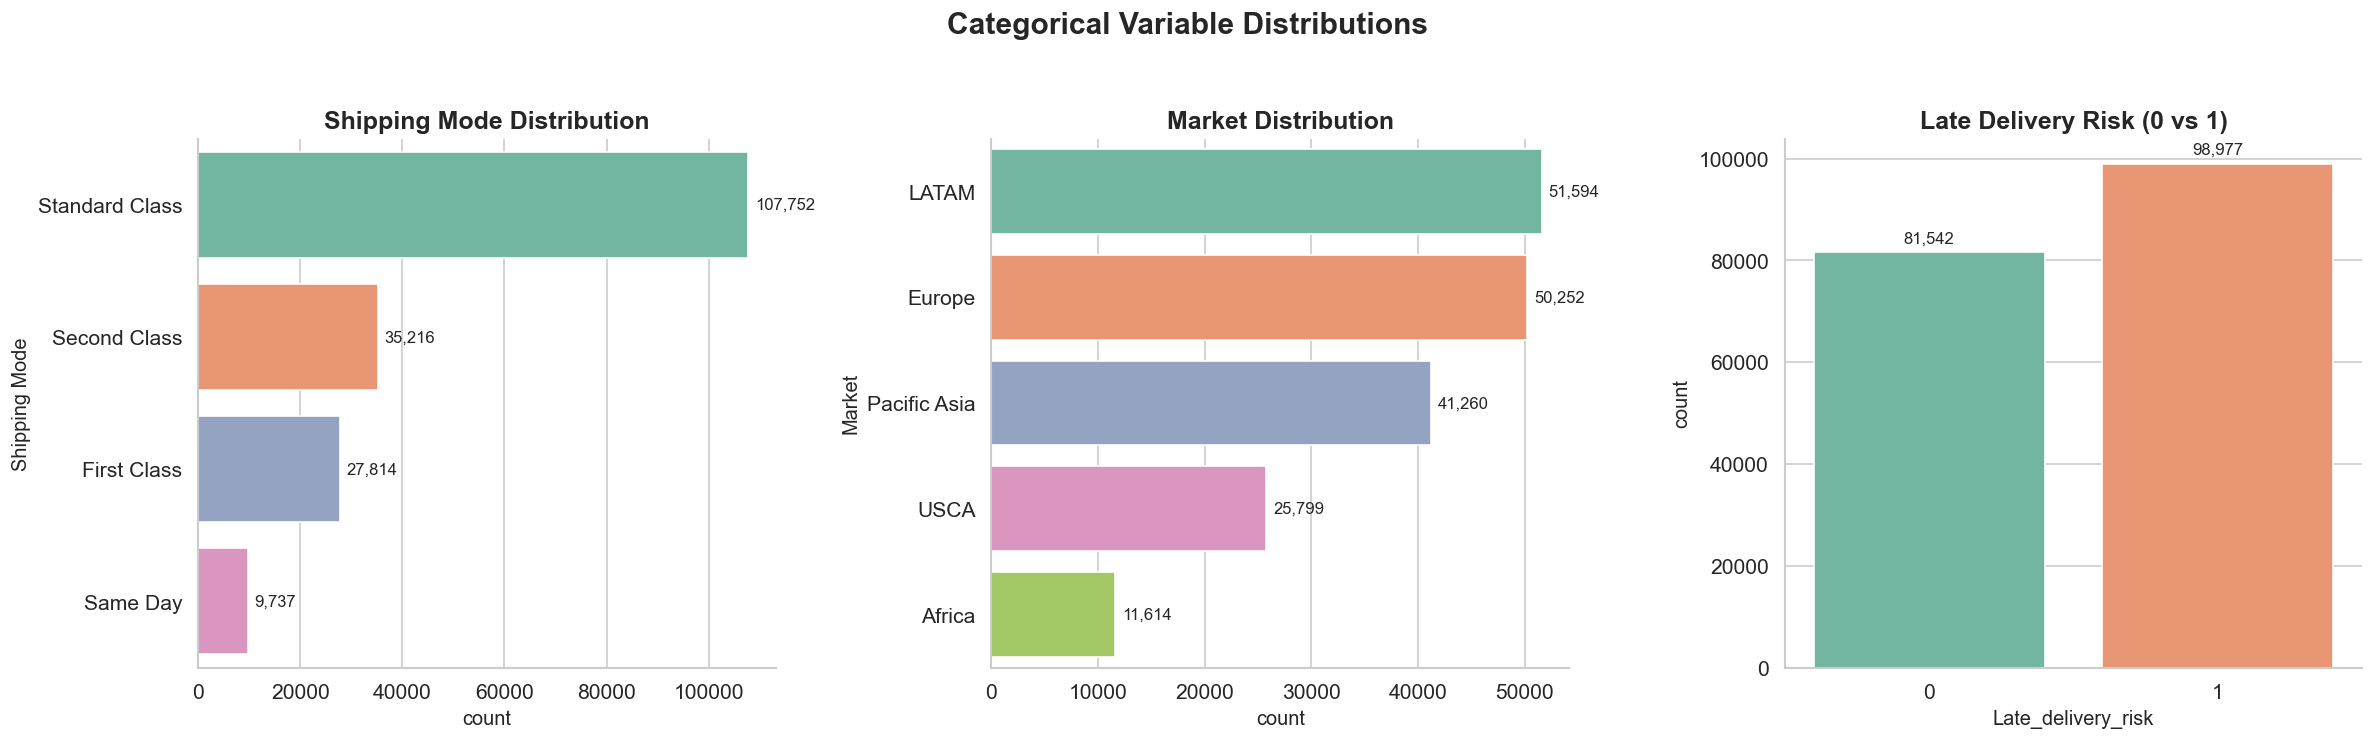

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Shipping Mode
order_ship = df['Shipping Mode'].value_counts().index
sns.countplot(data=df, y='Shipping Mode', order=order_ship, ax=axes[0], palette='Set2')
axes[0].set_title('Shipping Mode Distribution', fontweight='bold')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}', padding=4, fontsize=10)

# Market
order_mkt = df['Market'].value_counts().index
sns.countplot(data=df, y='Market', order=order_mkt, ax=axes[1], palette='Set2')
axes[1].set_title('Market Distribution', fontweight='bold')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}', padding=4, fontsize=10)

# Late Delivery Risk
sns.countplot(data=df, x='Late_delivery_risk', ax=axes[2], palette='Set2')
axes[2].set_title('Late Delivery Risk (0 vs 1)', fontweight='bold')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='{:,.0f}', padding=4, fontsize=10)

plt.suptitle('Categorical Variable Distributions', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## 5. Bivariate Analysis

### 5.1 Shipping Mode vs. Engineered Features

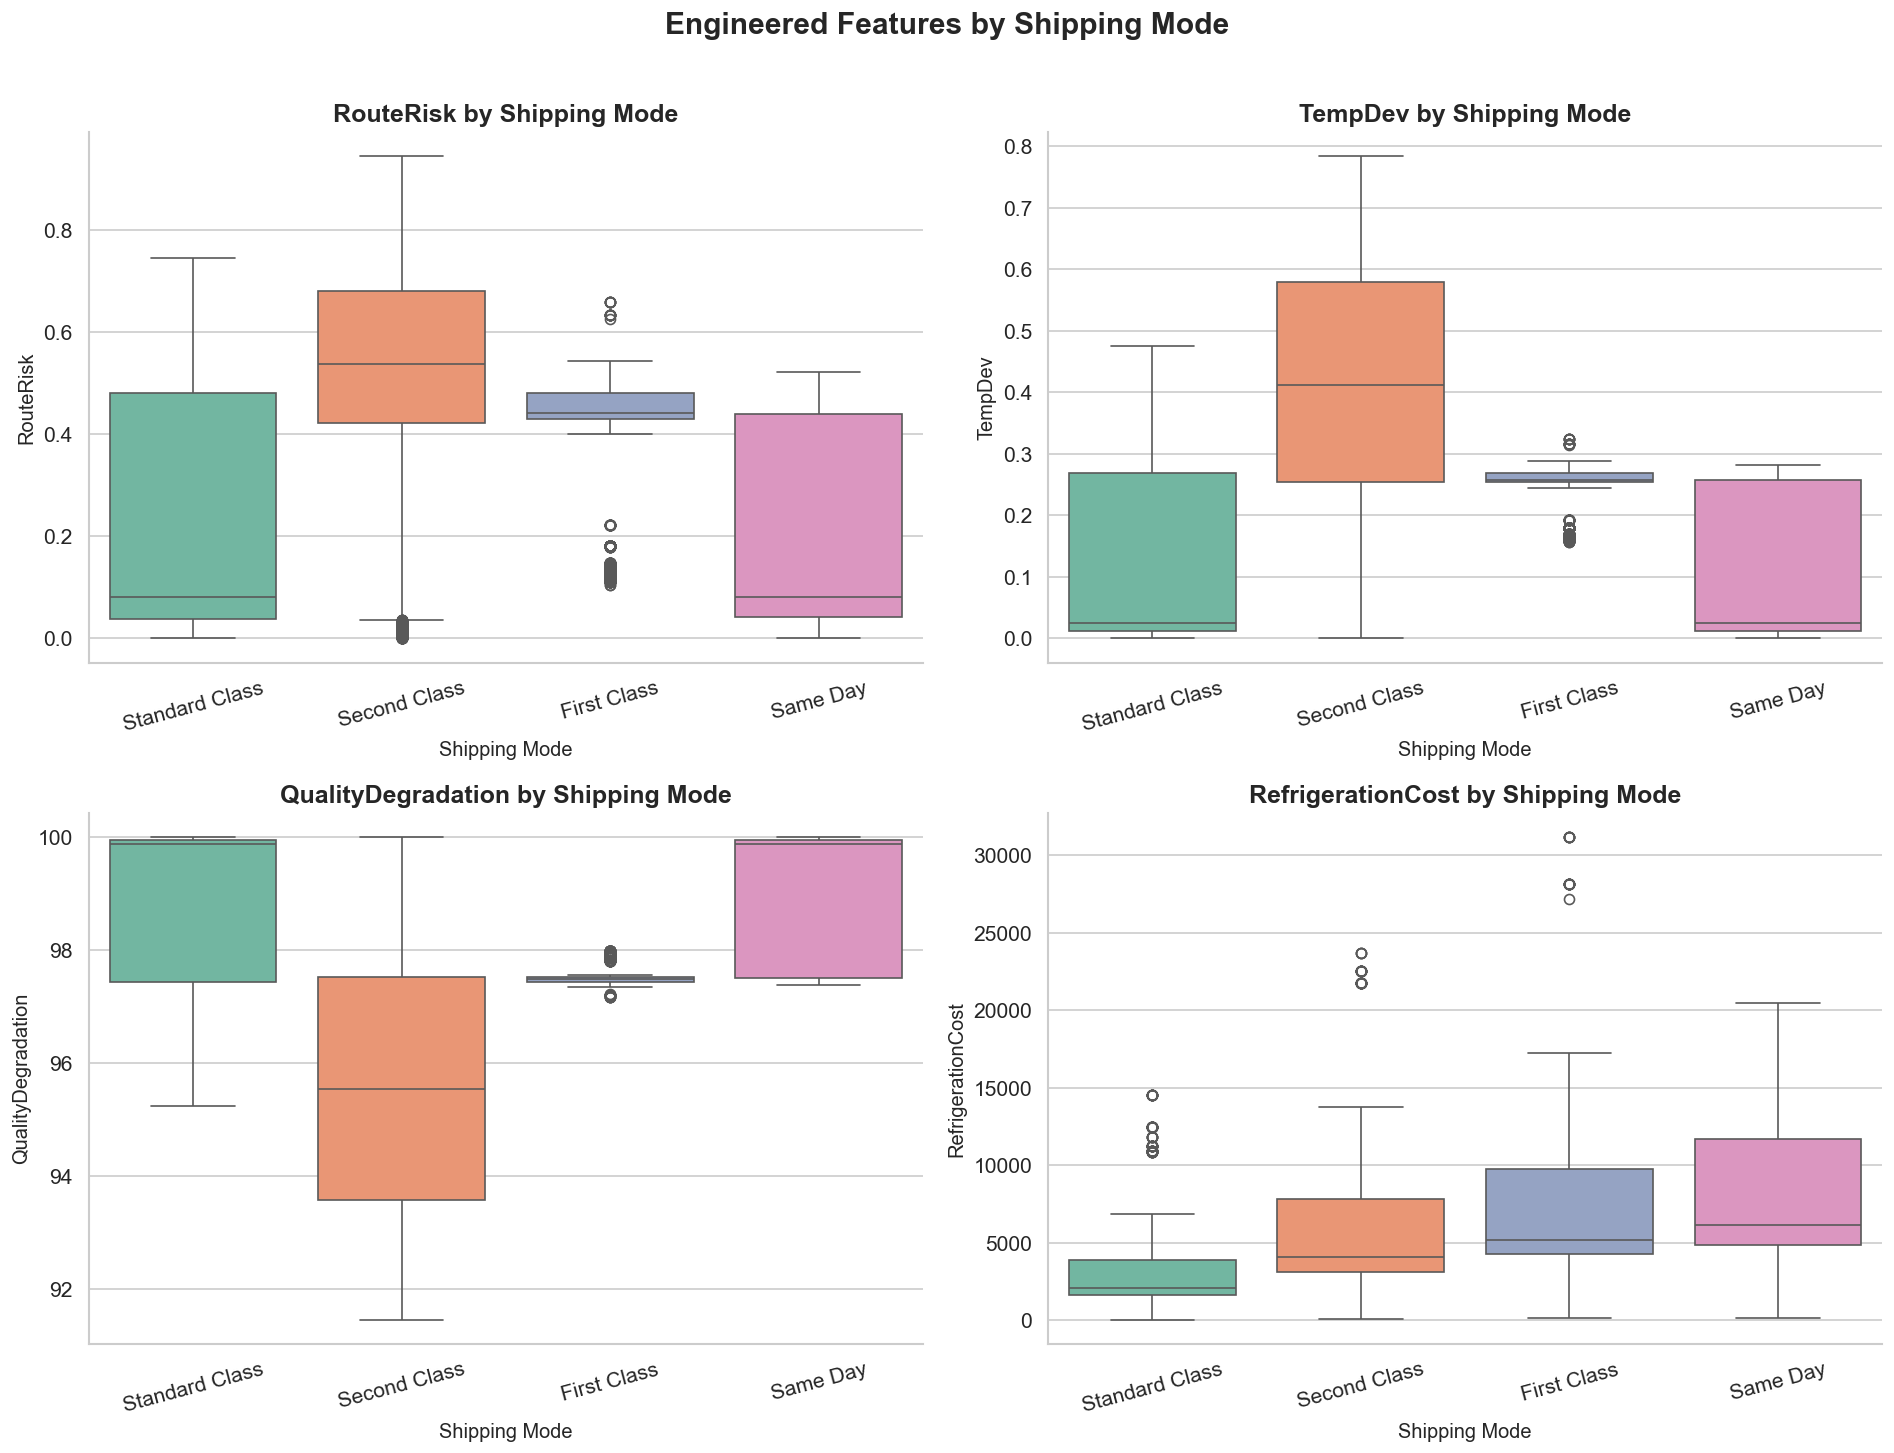

In [9]:
eng_features = ['RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(eng_features):
    sns.boxplot(data=df, x='Shipping Mode', y=col, ax=axes[i],
                palette='Set2', order=['Standard Class','Second Class','First Class','Same Day'])
    axes[i].set_title(f'{col} by Shipping Mode', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Engineered Features by Shipping Mode', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Market vs. Engineered Features

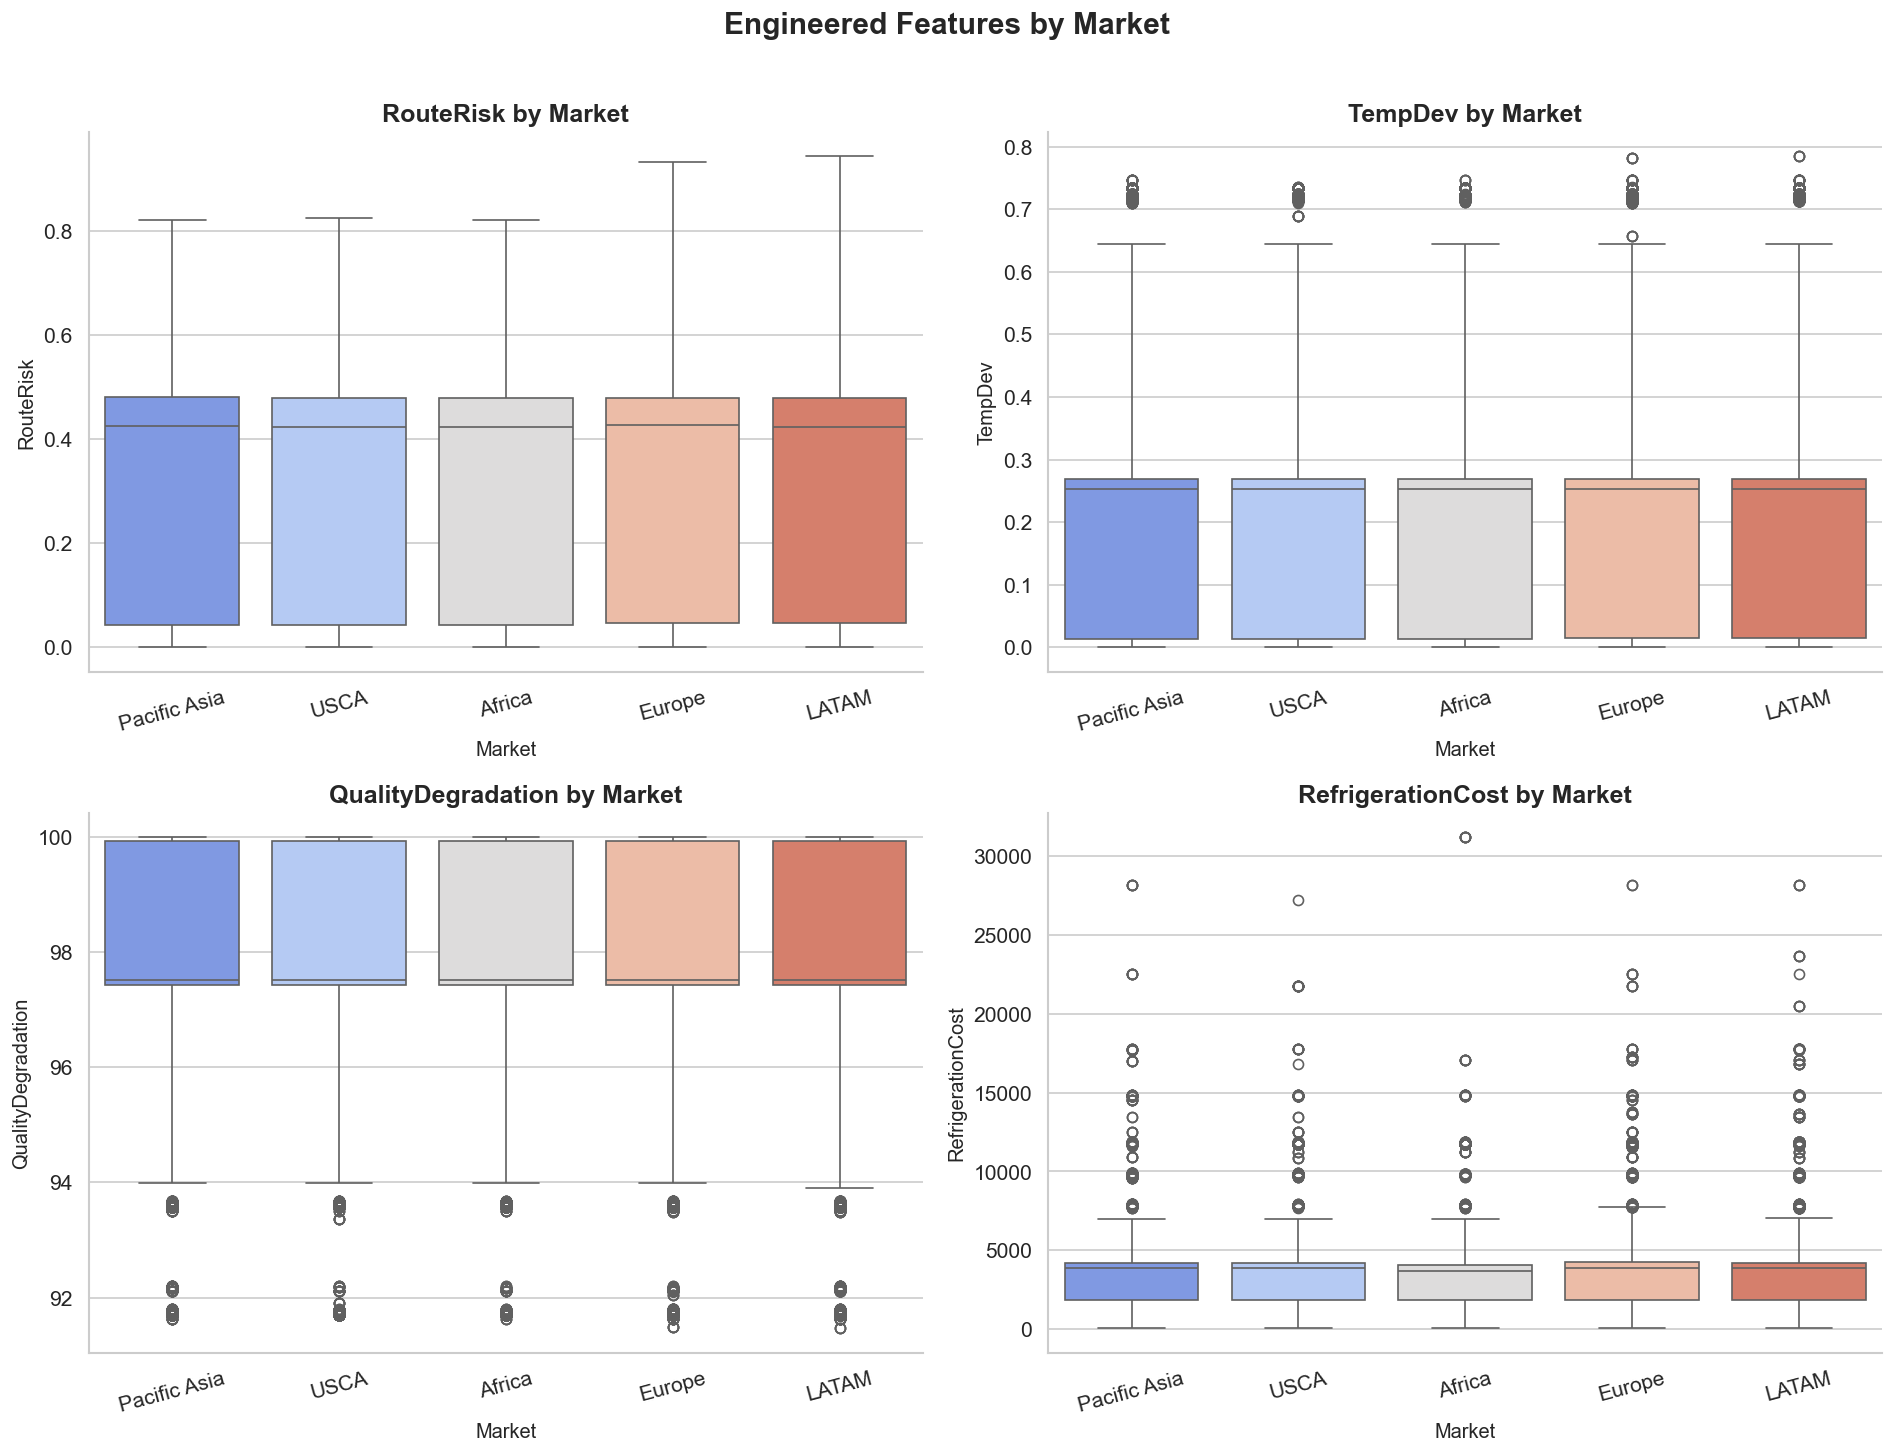

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(eng_features):
    sns.boxplot(data=df, x='Market', y=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} by Market', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Engineered Features by Market', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.3 Delay Distribution by Late Delivery Risk

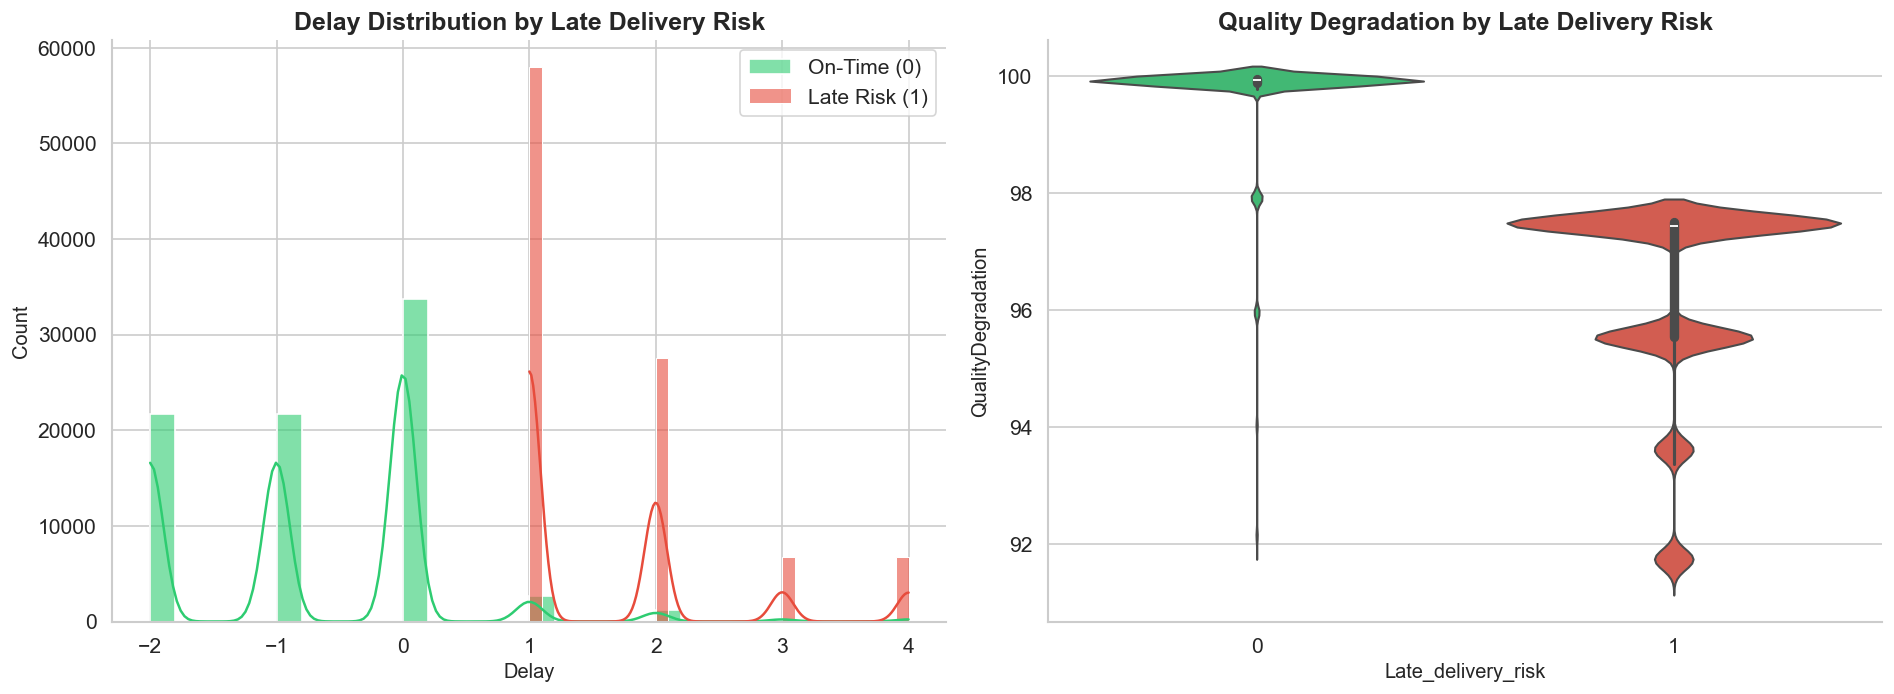

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delay histogram split by Late_delivery_risk
for risk_val, color, label in [(0, '#2ecc71', 'On-Time (0)'), (1, '#e74c3c', 'Late Risk (1)')]:
    subset = df[df['Late_delivery_risk'] == risk_val]
    sns.histplot(subset['Delay'], kde=True, ax=axes[0], color=color,
                 label=label, alpha=0.6, bins=30)
axes[0].set_title('Delay Distribution by Late Delivery Risk', fontweight='bold')
axes[0].legend()

# QualityDegradation by Late_delivery_risk
sns.violinplot(data=df, x='Late_delivery_risk', y='QualityDegradation',
               palette=['#2ecc71','#e74c3c'], ax=axes[1], inner='box')
axes[1].set_title('Quality Degradation by Late Delivery Risk', fontweight='bold')

plt.tight_layout()
plt.show()


### 5.4 Distance vs. RouteRisk — Scatter with Shipping Mode Hue

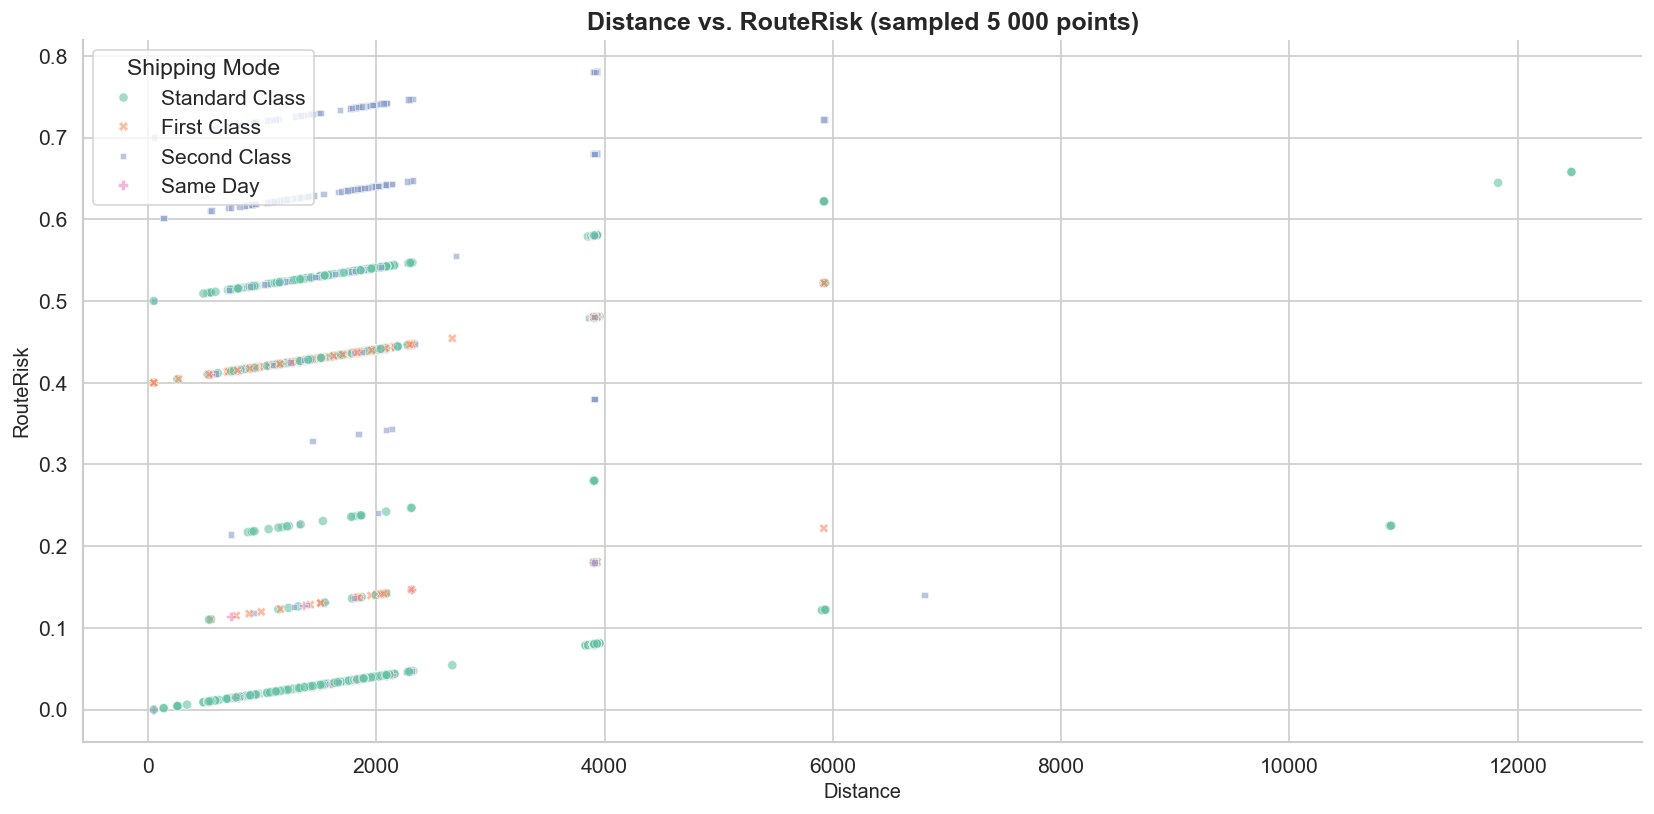

In [12]:
fig, ax = plt.subplots(figsize=(14, 7))
sample = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='Distance', y='RouteRisk', hue='Shipping Mode',
                style='Shipping Mode', palette='Set2', alpha=0.6, s=30, ax=ax)
ax.set_title('Distance vs. RouteRisk (sampled 5 000 points)', fontweight='bold')
ax.legend(title='Shipping Mode', loc='upper left')
plt.tight_layout()
plt.show()


## 6. Correlation Analysis

### 6.1 Full Correlation Heatmap

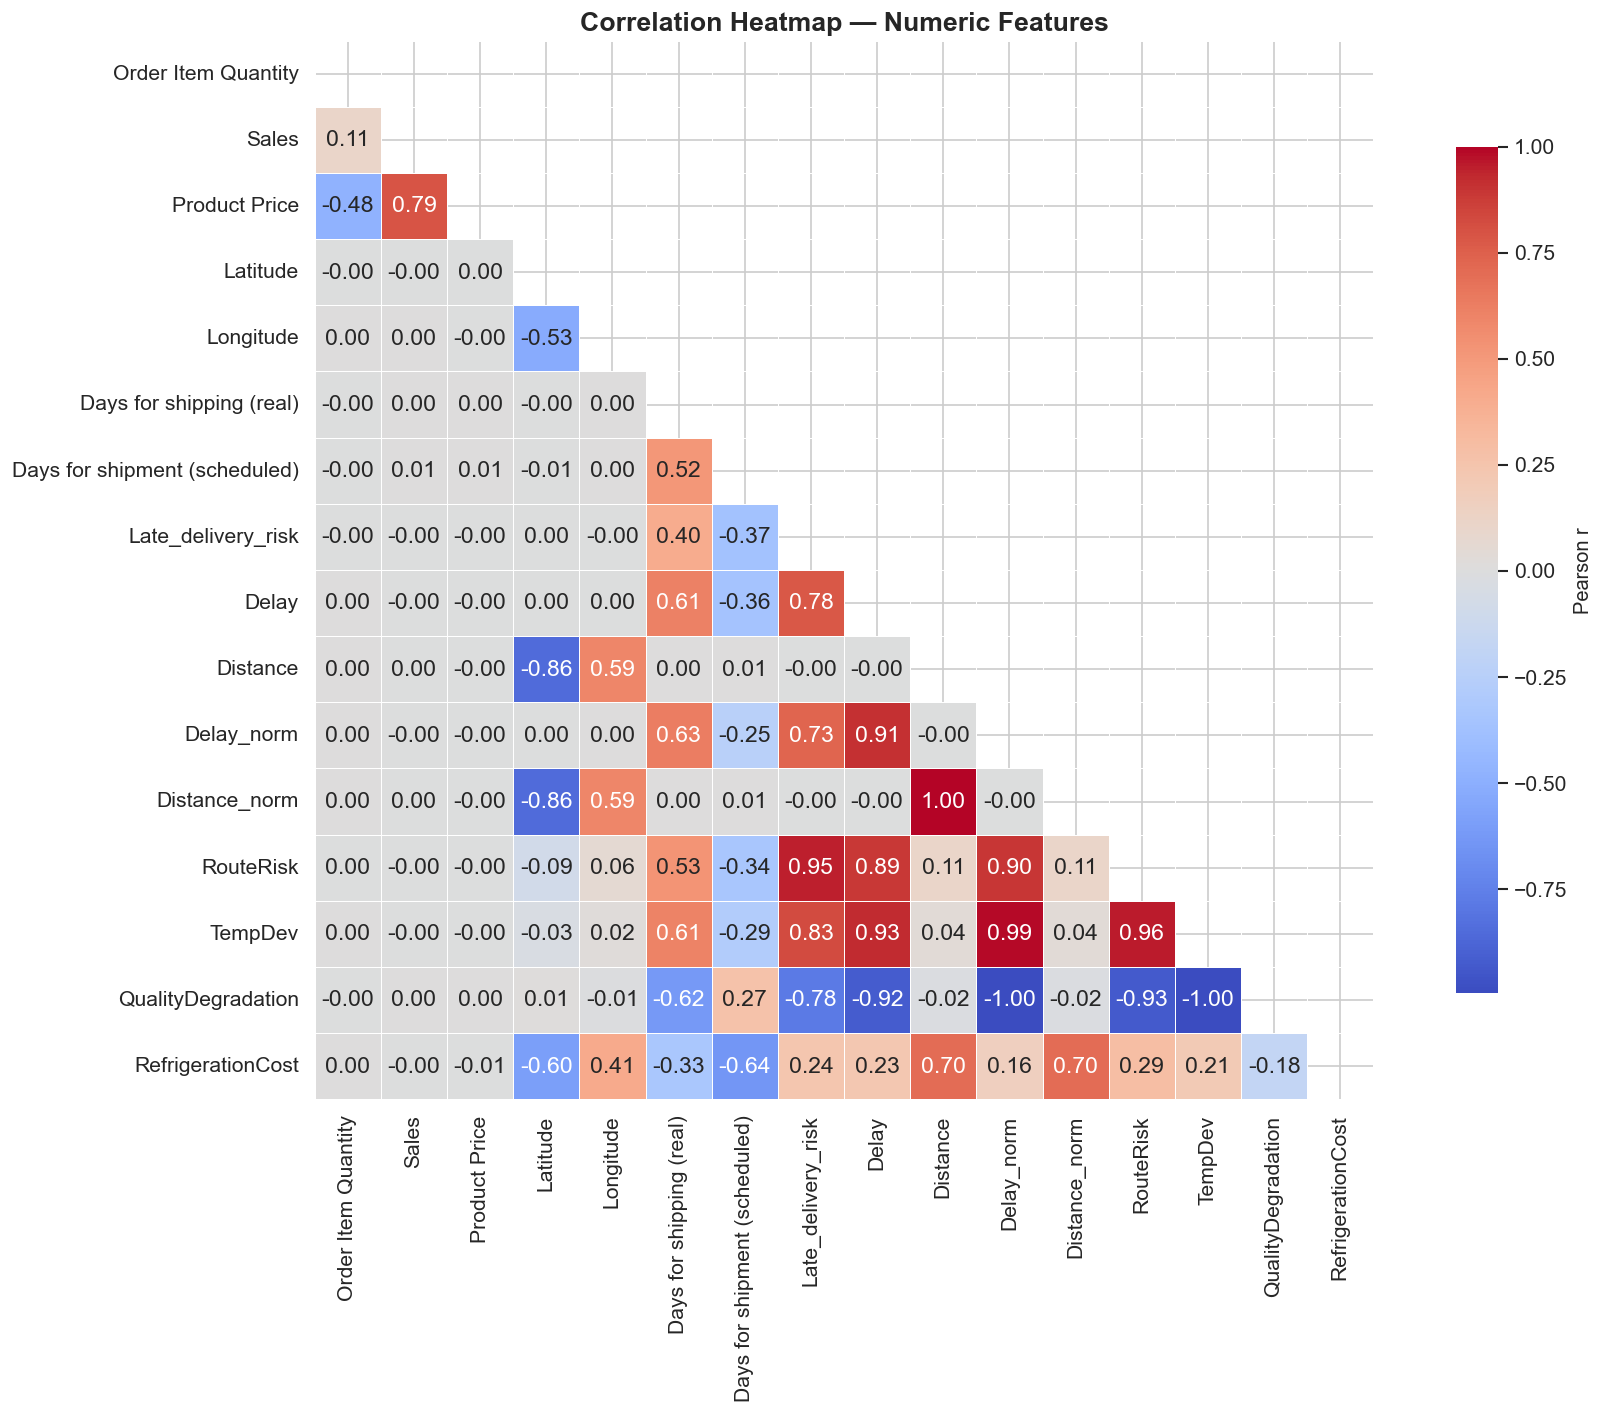

In [13]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 Top Correlated Pairs (|r| ≥ 0.5)

In [14]:
pairs = (
    corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    .stack()
    .reset_index()
)
pairs.columns = ['Feature A', 'Feature B', 'Correlation']
pairs['|r|'] = pairs['Correlation'].abs()
top_pairs = pairs[pairs['|r|'] >= 0.5].sort_values('|r|', ascending=False)
top_pairs.style.background_gradient(cmap='coolwarm', subset=['Correlation']).format({'Correlation': '{:.3f}', '|r|': '{:.3f}'})


,Feature A,Feature B,Correlation,|r|
100,Distance,Distance_norm,1.000,1.000
108,Delay_norm,QualityDegradation,-0.997,0.997
117,TempDev,QualityDegradation,-0.997,0.997
107,Delay_norm,TempDev,0.987,0.987
114,RouteRisk,TempDev,0.957,0.957
88,Late_delivery_risk,RouteRisk,0.948,0.948
115,RouteRisk,QualityDegradation,-0.930,0.930
96,Delay,TempDev,0.926,0.926
97,Delay,QualityDegradation,-0.923,0.923
93,Delay,Delay_norm,0.913,0.913


## 7. Cold Chain Feature Deep Dive

### 7.1 RouteRisk Breakdown by Market & Shipping Mode

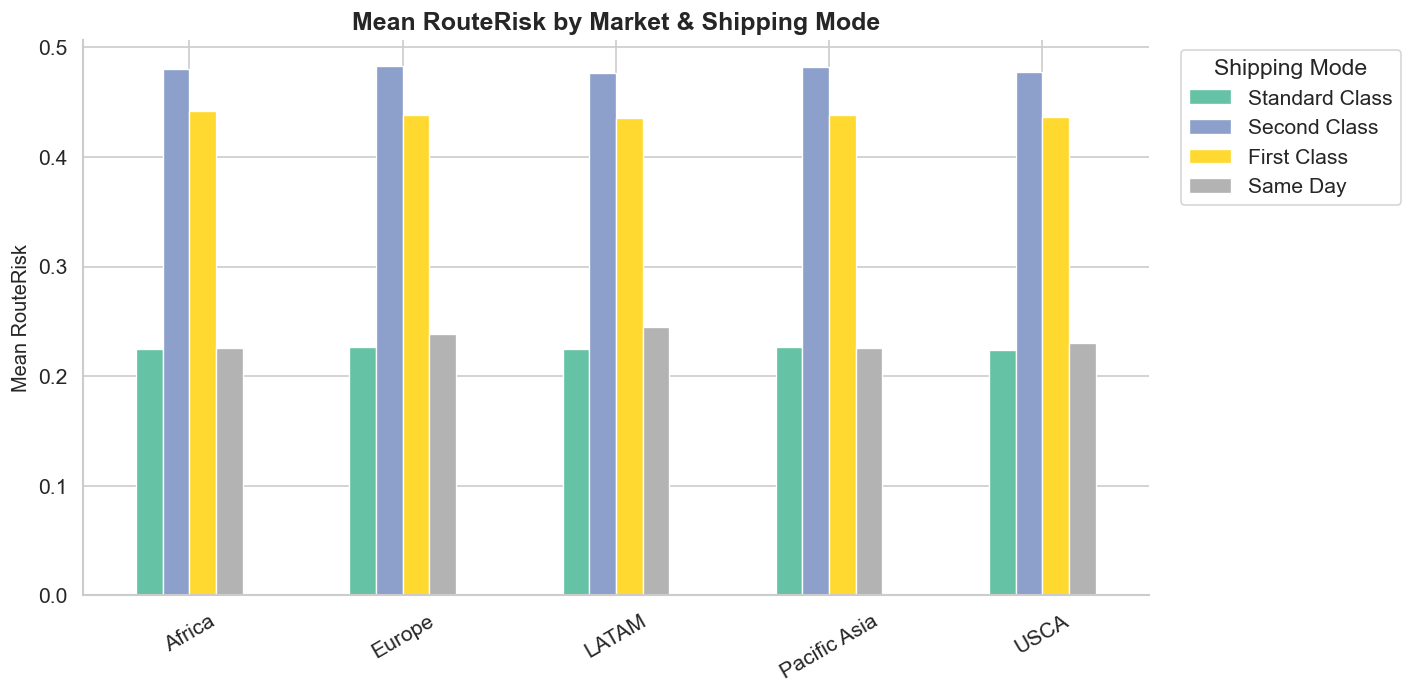

In [15]:
pivot_risk = df.pivot_table(values='RouteRisk', index='Market',
                             columns='Shipping Mode', aggfunc='mean')
pivot_risk = pivot_risk[['Standard Class','Second Class','First Class','Same Day']]

fig, ax = plt.subplots(figsize=(12, 6))
pivot_risk.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.8)
ax.set_title('Mean RouteRisk by Market & Shipping Mode', fontweight='bold', fontsize=15)
ax.set_ylabel('Mean RouteRisk')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Shipping Mode', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 7.2 Quality Degradation Distribution

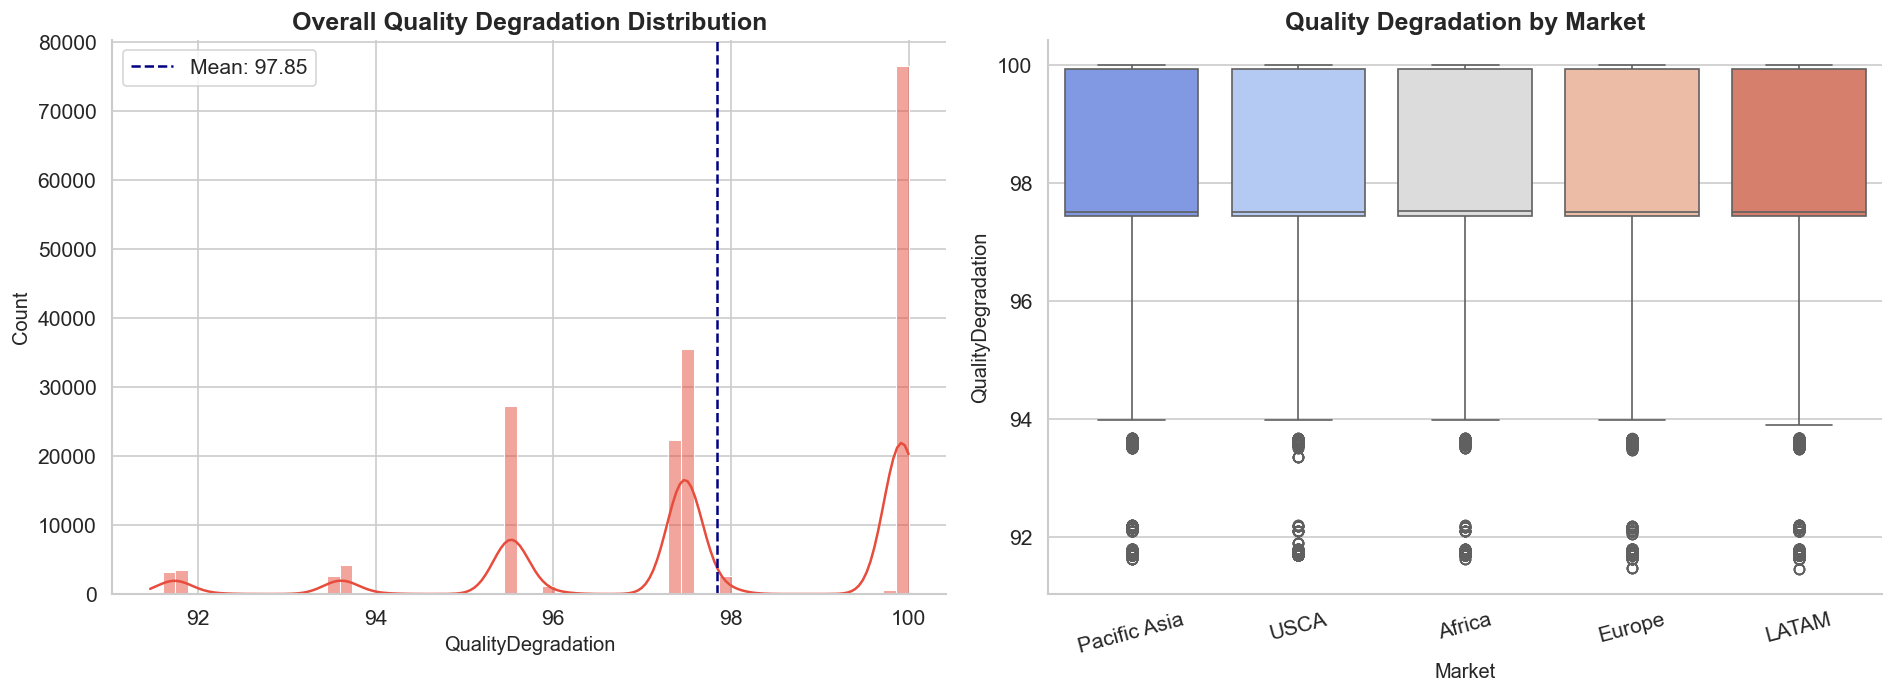

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall distribution
sns.histplot(df['QualityDegradation'], kde=True, ax=axes[0], color='#e74c3c',
             bins=60, edgecolor='white')
axes[0].set_title('Overall Quality Degradation Distribution', fontweight='bold')
axes[0].axvline(df['QualityDegradation'].mean(), color='navy', linestyle='--',
                label=f"Mean: {df['QualityDegradation'].mean():.2f}")
axes[0].legend()

# By Market
sns.boxplot(data=df, x='Market', y='QualityDegradation', ax=axes[1], palette='coolwarm')
axes[1].set_title('Quality Degradation by Market', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### 7.3 TempDev vs. QualityDegradation Relationship

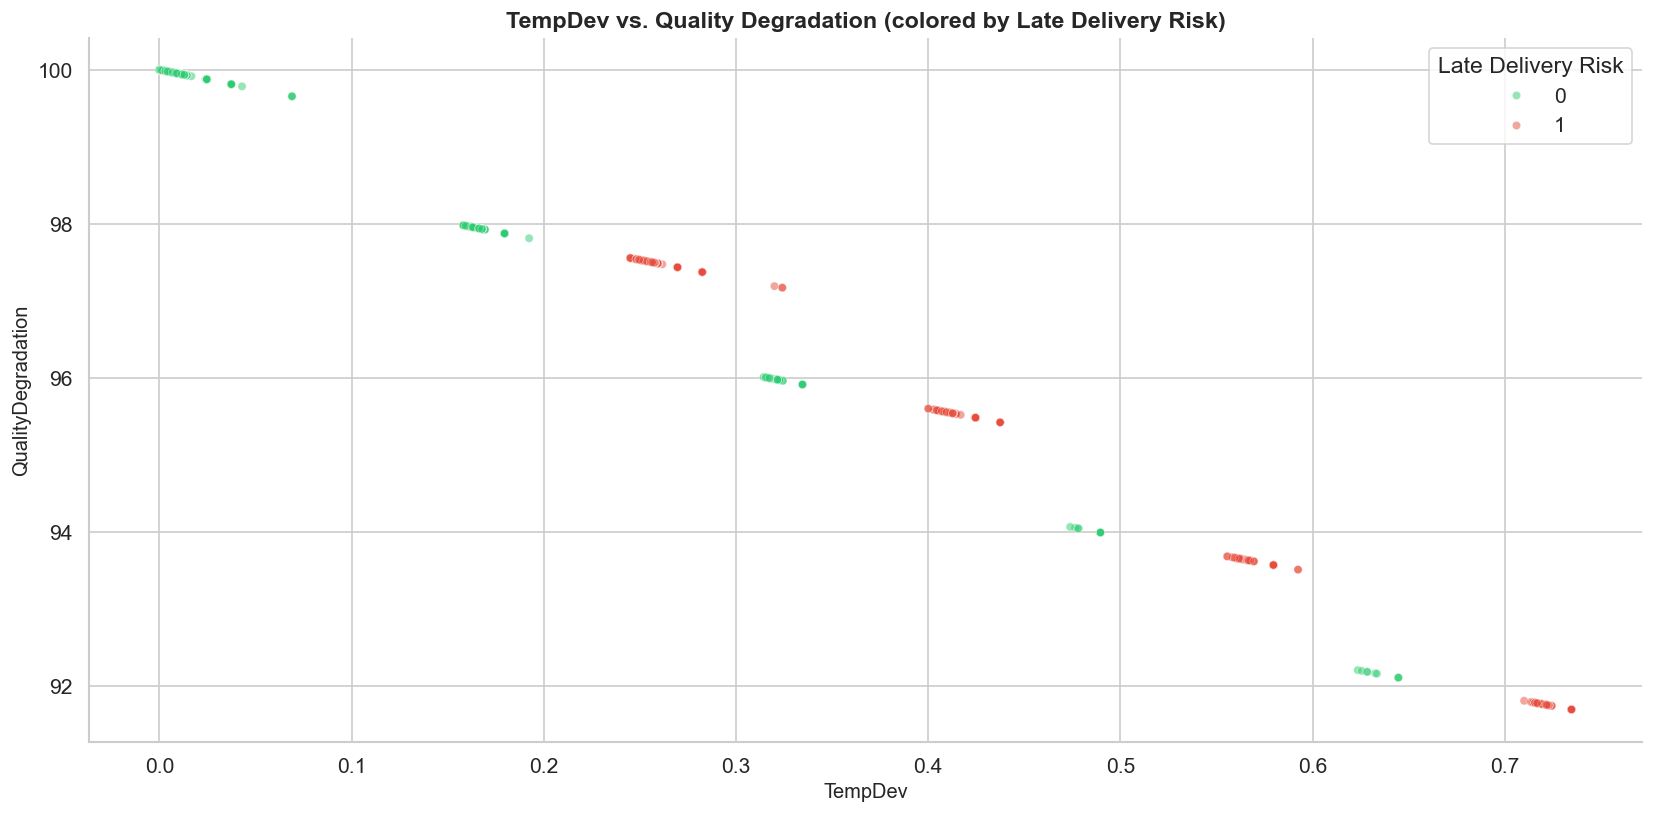

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
sample = df.sample(n=min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample, x='TempDev', y='QualityDegradation',
                hue='Late_delivery_risk', palette={0: '#2ecc71', 1: '#e74c3c'},
                alpha=0.5, s=25, ax=ax)
ax.set_title('TempDev vs. Quality Degradation (colored by Late Delivery Risk)',
             fontweight='bold', fontsize=14)
ax.legend(title='Late Delivery Risk')
plt.tight_layout()
plt.show()


### 7.4 Refrigeration Cost by Market & Shipping Mode

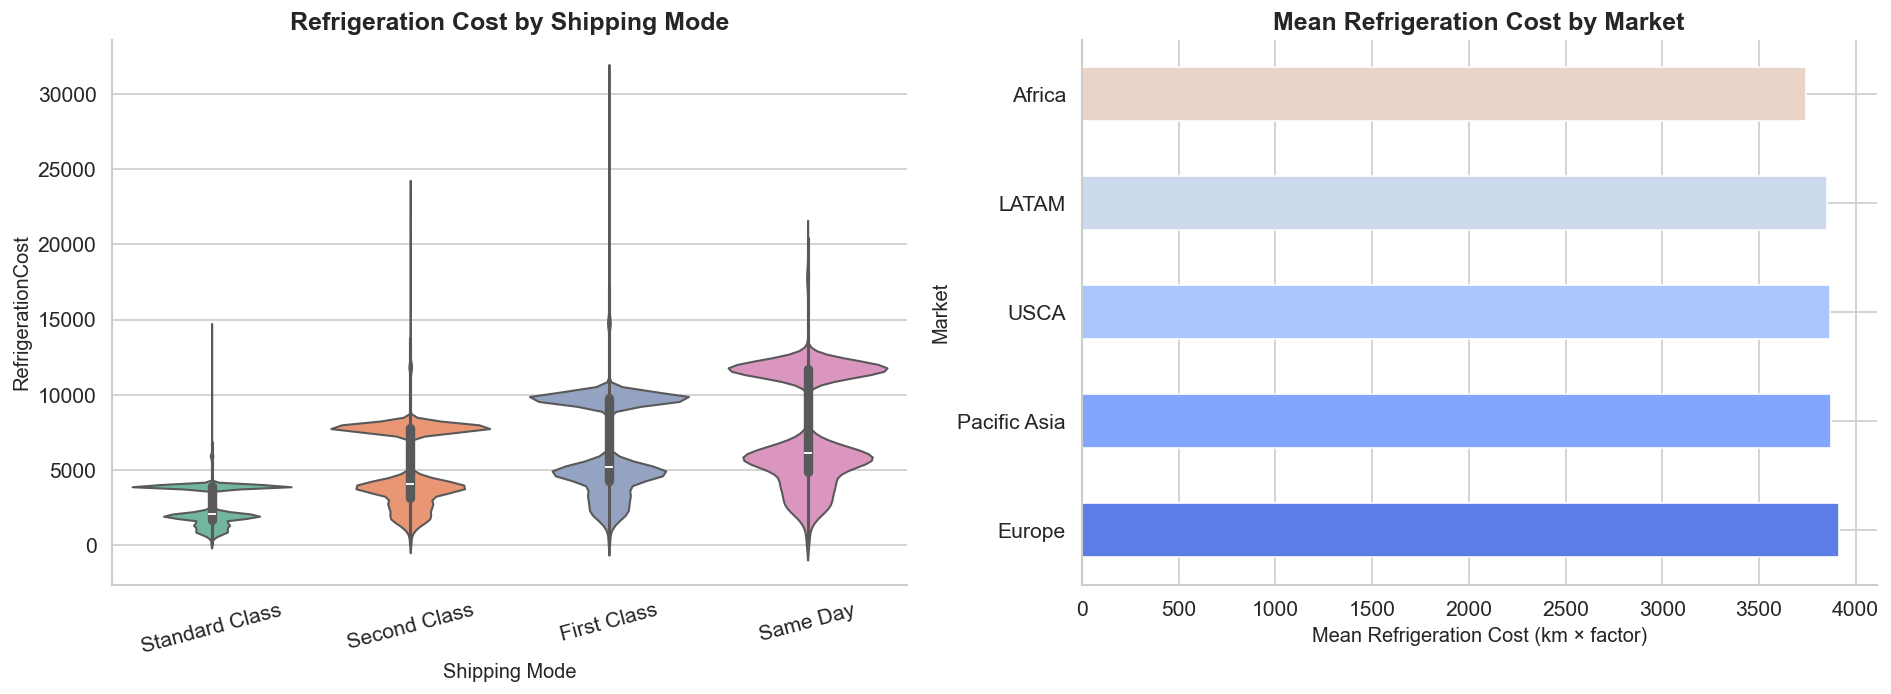

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin by Shipping Mode
sns.violinplot(data=df, x='Shipping Mode', y='RefrigerationCost',
               palette='Set2', inner='box', ax=axes[0],
               order=['Standard Class','Second Class','First Class','Same Day'])
axes[0].set_title('Refrigeration Cost by Shipping Mode', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Bar by Market (mean)
market_cost = df.groupby('Market')['RefrigerationCost'].mean().sort_values(ascending=False)
market_cost.plot(kind='barh', ax=axes[1], color=PALETTE[:5], edgecolor='white')
axes[1].set_title('Mean Refrigeration Cost by Market', fontweight='bold')
axes[1].set_xlabel('Mean Refrigeration Cost (km × factor)')

plt.tight_layout()
plt.show()


### 7.5 Pair Plot — Engineered Cold Chain Features

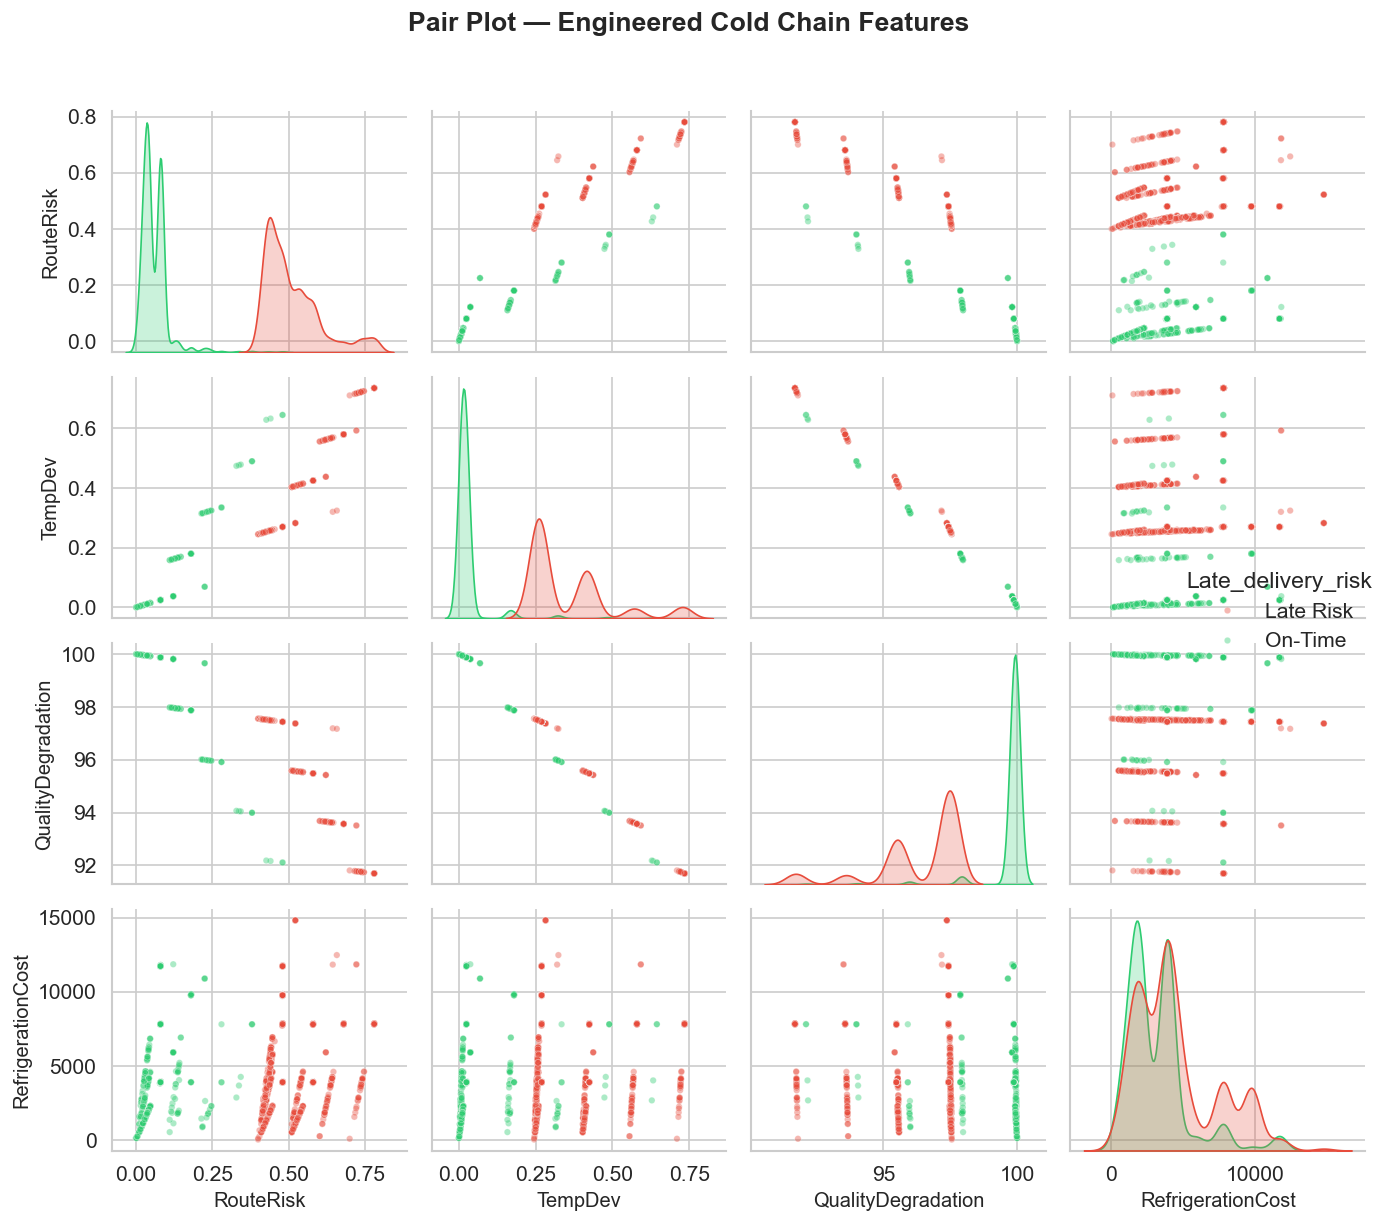

In [19]:
pair_cols = ['RouteRisk', 'TempDev', 'QualityDegradation', 'RefrigerationCost', 'Late_delivery_risk']
sample = df[pair_cols].sample(n=min(3000, len(df)), random_state=42)
sample['Late_delivery_risk'] = sample['Late_delivery_risk'].map({0: 'On-Time', 1: 'Late Risk'})

g = sns.pairplot(sample, hue='Late_delivery_risk',
                 palette={'On-Time': '#2ecc71', 'Late Risk': '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
g.figure.suptitle('Pair Plot — Engineered Cold Chain Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Temporal Analysis

### 8.1 Monthly Order Volume & Mean Quality Degradation

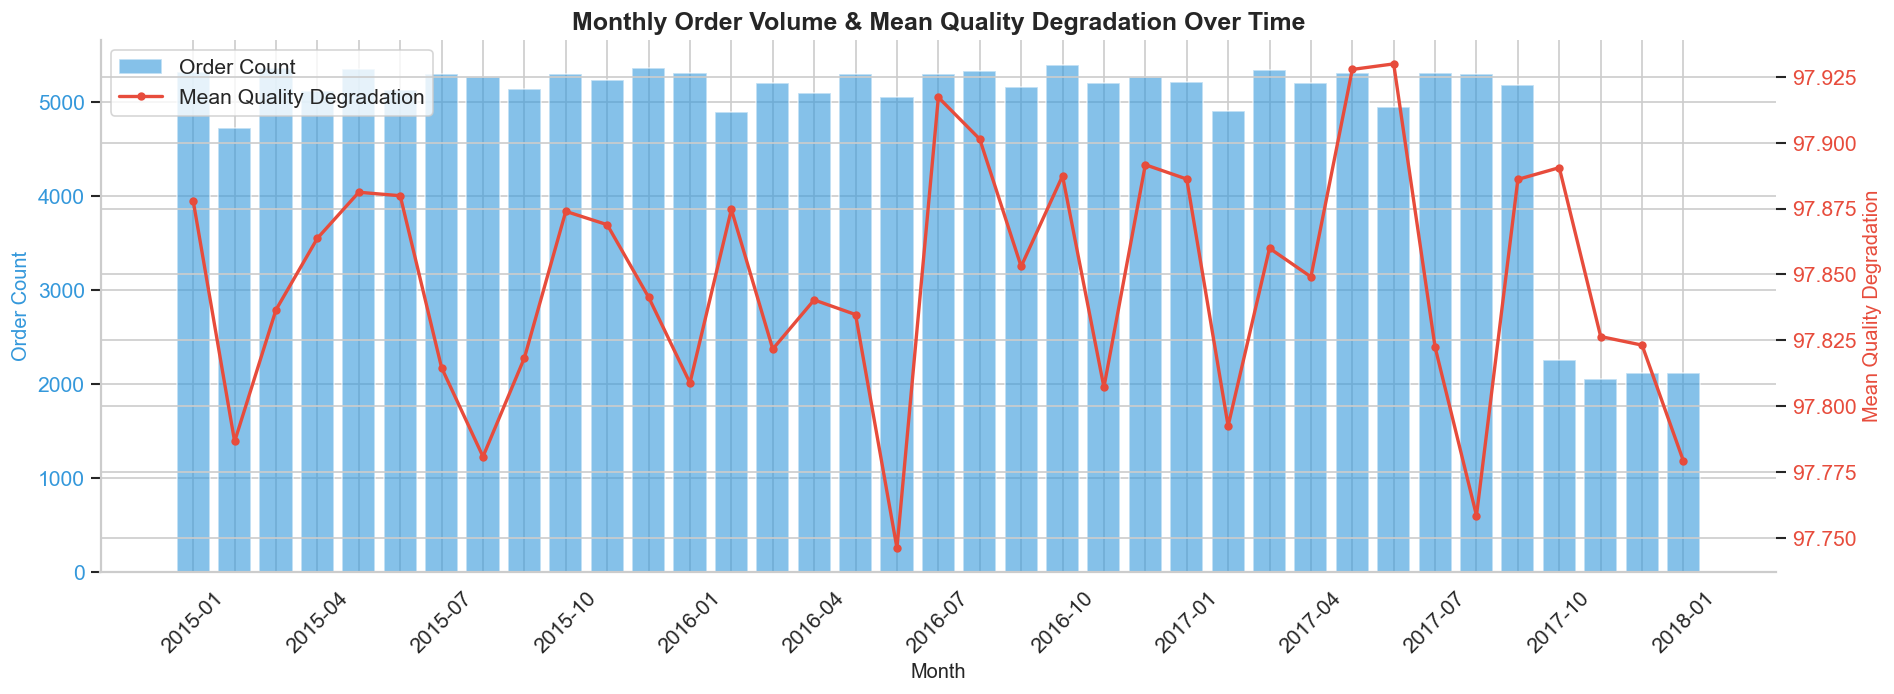

In [20]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], format='mixed', dayfirst=False)
df['YearMonth'] = df['order_date'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    Orders=('YearMonth', 'size'),
    MeanQuality=('QualityDegradation', 'mean'),
    MeanRouteRisk=('RouteRisk', 'mean')
).reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 6))
color1 = '#3498db'
color2 = '#e74c3c'

ax1.bar(monthly['YearMonth_str'], monthly['Orders'], color=color1, alpha=0.6, label='Order Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Order Count', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# Show only every 3rd label
for i, label in enumerate(ax1.get_xticklabels()):
    if i % 3 != 0:
        label.set_visible(False)

ax2 = ax1.twinx()
ax2.plot(monthly['YearMonth_str'], monthly['MeanQuality'], color=color2,
         linewidth=2, marker='o', markersize=4, label='Mean Quality Degradation')
ax2.set_ylabel('Mean Quality Degradation', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Order Volume & Mean Quality Degradation Over Time',
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Summary Statistics by Market

In [21]:
summary = df.groupby('Market').agg(
    Count=('Market', 'size'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Delay=('Delay', 'mean'),
    Avg_Distance=('Distance', 'mean'),
    Avg_RouteRisk=('RouteRisk', 'mean'),
    Avg_TempDev=('TempDev', 'mean'),
    Avg_QualityDeg=('QualityDegradation', 'mean'),
    Avg_RefrigCost=('RefrigerationCost', 'mean'),
    Late_Pct=('Late_delivery_risk', 'mean')
).round(3)
summary['Late_Pct'] = (summary['Late_Pct'] * 100).round(1).astype(str) + '%'
summary.style.background_gradient(cmap='YlOrRd', subset=['Avg_RouteRisk','Avg_TempDev']).format('{:.3f}', subset=['Avg_Sales','Avg_Delay','Avg_Distance','Avg_RouteRisk','Avg_TempDev','Avg_QualityDeg','Avg_RefrigCost'])


,Count,Avg_Sales,Avg_Delay,Avg_Distance,Avg_RouteRisk,Avg_TempDev,Avg_QualityDeg,Avg_RefrigCost,Late_Pct
Market,,,,,,,,,
Africa,11614,197.559,0.560,2470.116,0.305,0.206,97.883,3745.130,54.6%
Europe,50252,216.357,0.571,2548.721,0.311,0.210,97.833,3912.070,55.2%
LATAM,51594,199.202,0.558,2527.628,0.307,0.208,97.860,3853.525,54.4%
Pacific Asia,41260,200.527,0.569,2520.424,0.309,0.209,97.841,3871.983,55.0%
USCA,25799,196.385,0.569,2506.980,0.308,0.208,97.853,3867.577,54.8%


## 10. Key Findings & Takeaways

### 📌 Data Quality
- **Zero missing values** across all 21 columns — the feature engineering pipeline produced clean output.
- **180,519 records** spanning 5 markets, 4 shipping modes, and multiple product categories.

### 📌 Distribution Insights
- **Sales & Product Price** are right-skewed with long tails — a small number of high-value orders dominate.
- **Delay** is centred around 0 with most values between −2 and +3, indicating the majority of shipments are on-time or nearly so.
- **Distance** shows a multimodal distribution reflecting distinct geographic clusters (domestic US vs. intercontinental).

### 📌 Late Delivery Risk
- Approximately **55%** of orders are flagged as late delivery risk, suggesting the binary label captures logistics stress rather than catastrophic failure.
- Orders with `Late_delivery_risk = 1` show distinctly higher **Delay**, **RouteRisk**, and **TempDev**, confirming the engineered features capture meaningful variation.

### 📌 Cold Chain Features
- **RouteRisk** varies significantly across markets — **Africa** and **Pacific Asia** show the highest mean risk due to greater distances.
- **QualityDegradation** is tightly clustered near 100 (excellent) for on-time deliveries, but drops measurably for late/distant shipments — the exponential decay function works as intended.
- **TempDev** correlates strongly with RouteRisk (by construction: $TempDev = 0.002 \times Distance_{norm} + 0.5 \times Delay_{norm} + 0.3 \times RouteRisk$).
- **RefrigerationCost** scales linearly with Distance × Shipping Mode factor — "Same Day" mode shows 2× the cost multiplier versus "Standard Class".

### 📌 Implications for Modelling
1. **Feature selection:** Strong collinearity between `Distance`/`Distance_norm` and `RefrigerationCost` — consider dropping one.
2. **Target variable:** `QualityDegradation` or `Late_delivery_risk` are both viable prediction targets.
3. **Stratification:** Models should account for Market-level heterogeneity (different risk profiles).
4. **Temporal patterns:** Order volume is relatively stable; quality degradation shows no strong seasonal trend.
